In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

Question 01

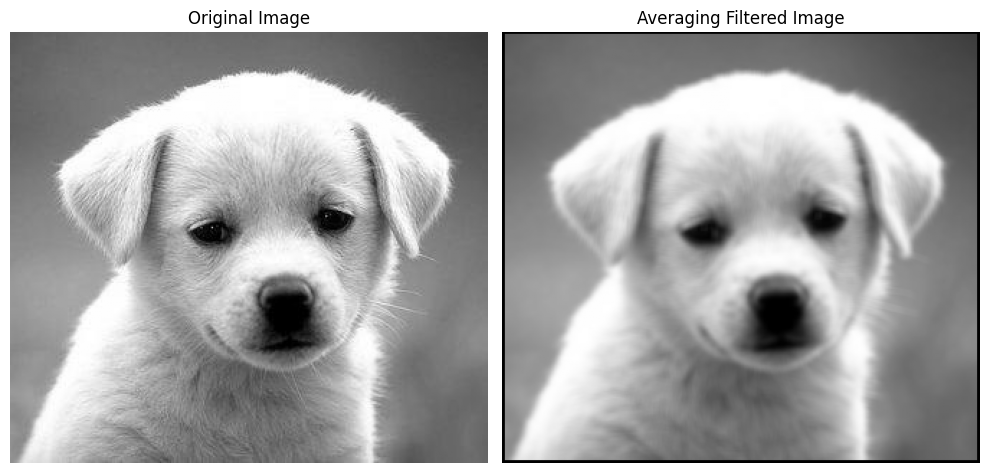

In [4]:
# Read the image in grayscale mode
image = cv2.imread('Gray_Scale_Image.jpg', 0)

# Check whether image is loaded correctly
if image is None:
    print("Error: Image not found!")
    exit()

# Get image dimensions
m, n = image.shape

# Create a 5x5 averaging mask
mask = np.ones((5, 5), dtype=float) / 25

# Create empty image for output
image_new = np.zeros((m, n), dtype=np.uint8)

# Apply 5x5 averaging filter
for i in range(2, m - 2):
    for j in range(2, n - 2):

        temp = (
            image[i-2, j-2] * mask[0, 0] +
            image[i-2, j-1] * mask[0, 1] +
            image[i-2, j]   * mask[0, 2] +
            image[i-2, j+1] * mask[0, 3] +
            image[i-2, j+2] * mask[0, 4] +

            image[i-1, j-2] * mask[1, 0] +
            image[i-1, j-1] * mask[1, 1] +
            image[i-1, j]   * mask[1, 2] +
            image[i-1, j+1] * mask[1, 3] +
            image[i-1, j+2] * mask[1, 4] +

            image[i, j-2] * mask[2, 0] +
            image[i, j-1] * mask[2, 1] +
            image[i, j]   * mask[2, 2] +
            image[i, j+1] * mask[2, 3] +
            image[i, j+2] * mask[2, 4] +

            image[i+1, j-2] * mask[3, 0] +
            image[i+1, j-1] * mask[3, 1] +
            image[i+1, j]   * mask[3, 2] +
            image[i+1, j+1] * mask[3, 3] +
            image[i+1, j+2] * mask[3, 4] +

            image[i+2, j-2] * mask[4, 0] +
            image[i+2, j-1] * mask[4, 1] +
            image[i+2, j]   * mask[4, 2] +
            image[i+2, j+1] * mask[4, 3] +
            image[i+2, j+2] * mask[4, 4]
        )

        # Store result
        image_new[i, j] = temp

# Convert to unsigned 8-bit integer
image_new = image_new.astype(np.uint8)

# Save filtered image
cv2.imwrite('Averaging Filtered Image.tif', image_new)

# Display original image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Display filtered image
plt.subplot(1, 2, 2)
plt.imshow(image_new, cmap='gray')
plt.title('Averaging Filtered Image')
plt.axis('off')

plt.tight_layout()
plt.show()

Question 02

(np.float64(-0.5), np.float64(183.5), np.float64(273.5), np.float64(-0.5))

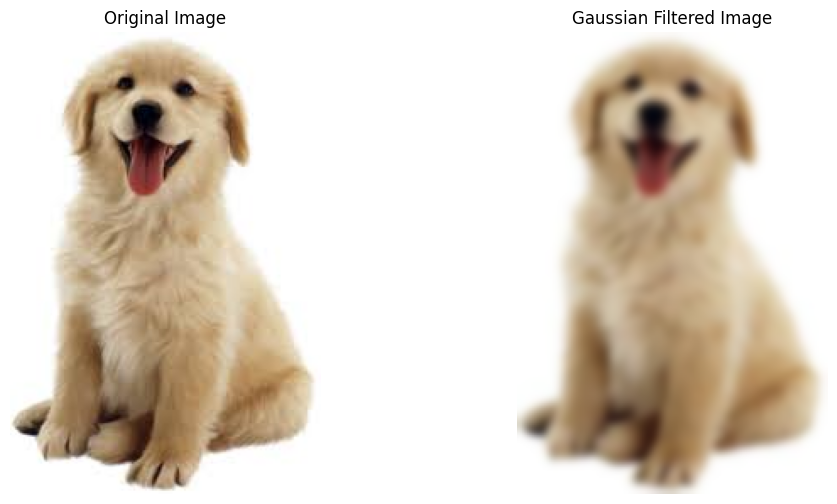

In [5]:
# load the image
image = cv2.imread('color_image.jpg', cv2.IMREAD_COLOR)

# convert from BGR to RGB for correct color display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# apply gaussian filter
kernel_size = (15, 15)
sigma_value = 0 # sigma define the blur strength, 0 means that openCV  will automatically calculate the optimal value for
gaussian_blur = cv2.GaussianBlur(image_rgb, kernel_size, sigma_value)

# create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# display the original image
axes[0].imshow(image_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

# display the gaussian filter image
axes[1].imshow(gaussian_blur)
axes[1].set_title('Gaussian Filtered Image')
axes[1].axis('off')

Question 03

(np.float64(-0.5), np.float64(183.5), np.float64(273.5), np.float64(-0.5))

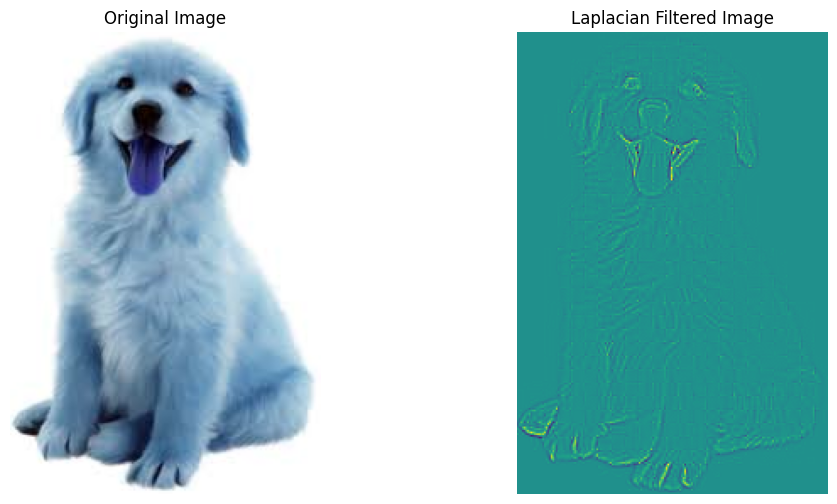

In [6]:
# load the image
image = cv2.imread('color_image.jpg', cv2.IMREAD_COLOR)

# convert from BGR to RGB for correct color display
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# apply laplacian filter
laplacian = cv2.Laplacian(gray_image, cv2.CV_64F)

# create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# display the original image
axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

# display the gaussian filter image
axes[1].imshow(laplacian)
axes[1].set_title('Laplacian Filtered Image')
axes[1].axis('off')

Question 04

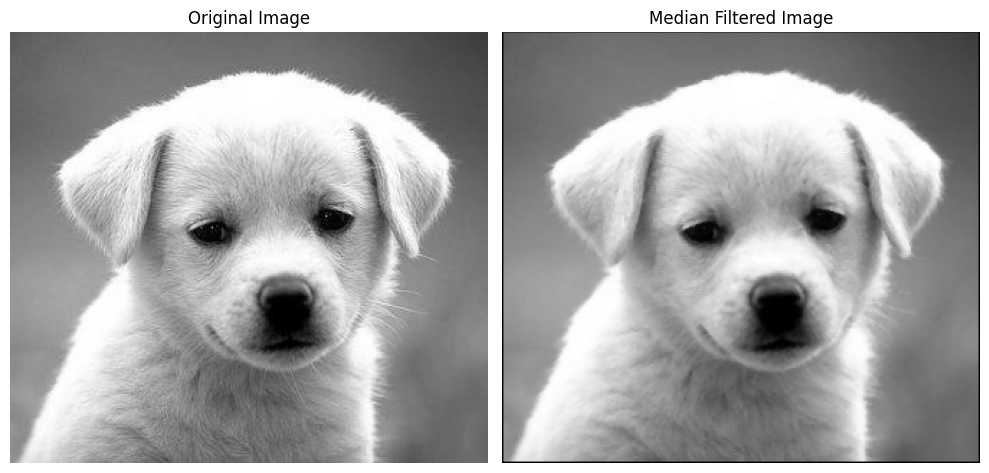

In [7]:
# Read the image in grayscale mode
# 0 means grayscale image
image_noisy1 = cv2.imread('Gray_Scale_Image.jpg', 0)

# Get image dimensions
m, n = image_noisy1.shape

# Create an empty image for output
img_new1 = np.zeros((m, n), dtype=np.uint8)

# Apply Median Filter
for i in range(1, m - 1):
    for j in range(1, n - 1):

        # Extract 3x3 neighboring pixels
        temp = [
            image_noisy1[i - 1, j - 1],
            image_noisy1[i - 1, j],
            image_noisy1[i - 1, j + 1],
            image_noisy1[i, j - 1],
            image_noisy1[i, j],
            image_noisy1[i, j + 1],
            image_noisy1[i + 1, j - 1],
            image_noisy1[i + 1, j],
            image_noisy1[i + 1, j + 1]
        ]

        # Sort the pixel values
        temp.sort()

        # Assign the median value
        img_new1[i, j] = temp[4]

# Save the filtered image
cv2.imwrite('new_median_filter_image.png', img_new1)

# Display Original Image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_noisy1, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Display Median Filtered Image
plt.subplot(1, 2, 2)
plt.imshow(img_new1, cmap='gray')
plt.title('Median Filtered Image')
plt.axis('off')

plt.tight_layout()
plt.show()